In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv('daily-minimum-temperatures-in-me.csv')

In [3]:
data.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


In [4]:
data['Date']=pd.to_datetime(data['Date'])

In [5]:
data.set_index('Date',inplace=True)

In [6]:
data.head()

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [8]:
bad = data.loc[
    pd.to_numeric(data['Daily minimum temperatures'], errors='coerce').isna(),
    'Daily minimum temperatures'
]

print(bad)

Date
1982-07-20    ?0.2
1982-07-21    ?0.8
1984-07-14    ?0.1
Name: Daily minimum temperatures, dtype: object


In [9]:
data['Daily minimum temperatures']=data['Daily minimum temperatures'].str.replace("?","")

In [10]:
data['Daily minimum temperatures']=data['Daily minimum temperatures'].astype(float)

In [11]:
data.dtypes

Daily minimum temperatures    float64
dtype: object

In [24]:
data.shape

(3650, 1)

In [12]:
import matplotlib.pyplot as plt

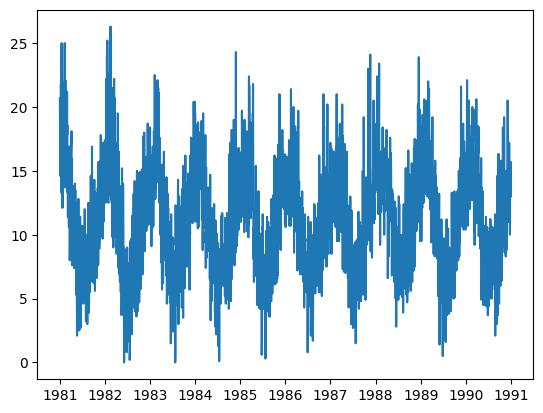

In [13]:
plt.plot(data,data=data)
plt.show()


In [15]:
from statsmodels.tsa.stattools import adfuller,kpss

In [16]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())

In [17]:
adf_test(data['Daily minimum temperatures'])

adf stats:-4.445
p-value stats:0.0
lags values:20
1%:-3.432
5%:-2.862
10%:-2.567


In [18]:
kpss_test(data['Daily minimum temperatures'])

KPSS Statistic: 0.049232800518522864
p-value: 0.1
Lags used: 36
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_26880\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

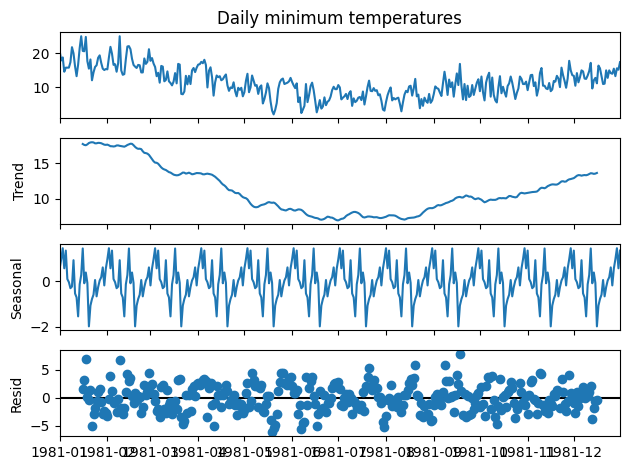

In [31]:
result=seasonal_decompose(data['Daily minimum temperatures'].iloc[:365],model='additive',period=30)
result.plot()
plt.show()

In [25]:
from scipy.stats import ks_2samp

In [26]:
first_half=data[:len(data['Daily minimum temperatures'])//2]
second_half=data[len(data['Daily minimum temperatures'])//2:]

In [27]:
first_half.shape

(1825, 1)

In [28]:
second_half.shape

(1825, 1)

In [29]:
stats,p=ks_2samp(first_half,second_half)

In [30]:
p

array([0.01422239])

In [36]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

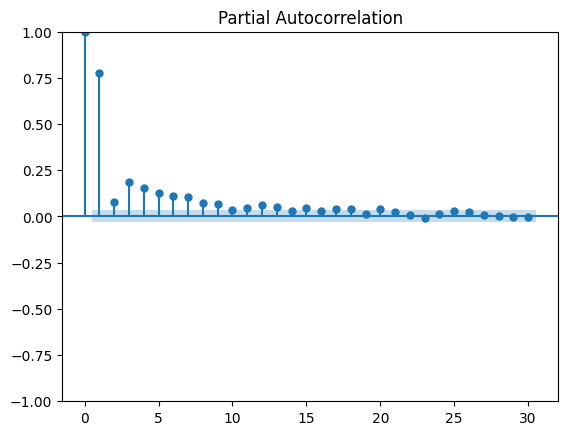

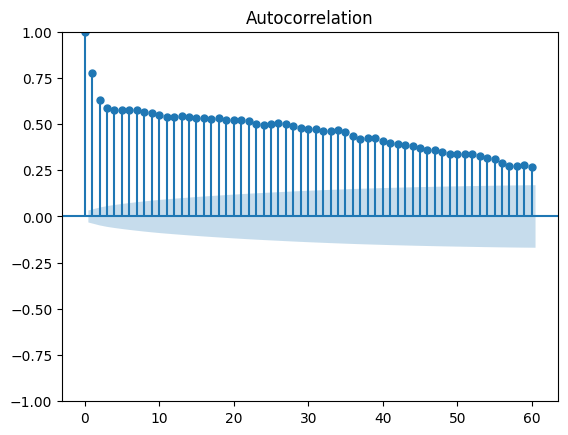

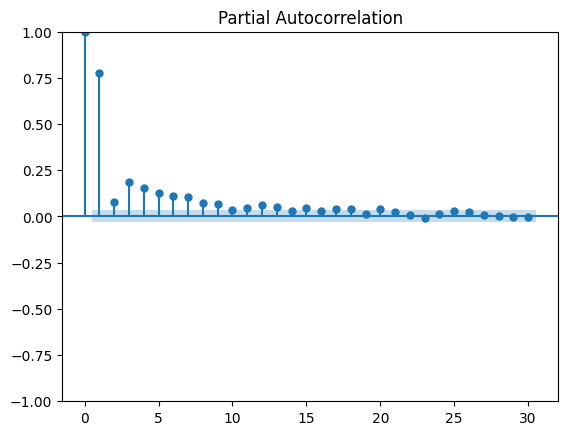

In [42]:
plot_acf(data['Daily minimum temperatures'],lags=60)
plot_pacf(data['Daily minimum temperatures'],lags=30)

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
train=data.iloc[:3600]
test=data.iloc[3600:]

In [51]:
model = SARIMAX(
    train,
    order=(12, 0, 12),
    seasonal_order=(1, 0, 1, 30)
)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [52]:
result=model.fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
forecast = result.forecast(steps=len(test))

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


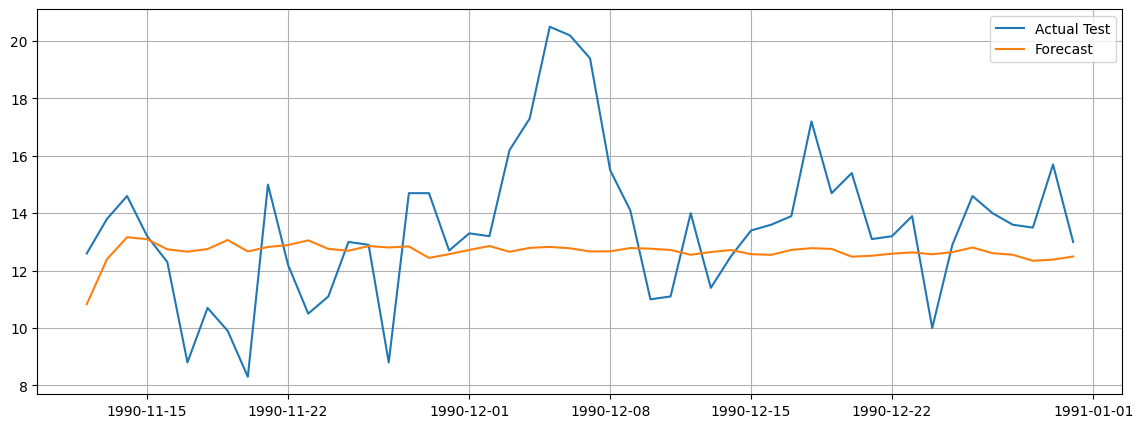

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))


plt.plot(test.index, test, label='Actual Test')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.grid(True)
plt.show()

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2.046755031326114
RMSE: 2.7177475270861486
